In [26]:
import pandas as pd
import requests
import numpy as np
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [28]:
#url de la API
api_url='https://api.yelp.com/v3/businesses/search'

#estos datos corresponden a una cuenta de usuario creada previamente
clientid='GWOCZh9-BmZxtdsAjr7Gug'
apikey='FHVvXoNmTXIl9DuxYis7AV5uLPujm9MLwrhgs5NgvCfaOxd3V6mxt6dQU8eEqYJiGxe816XATx7ufWjbMWqbV-2Uku1jxBJv8BGRC74NroLPl27PDQqs0tDixit-YHYx'
headers={'Authorization':'Bearer %s'%apikey}

In [29]:
ciudad = "Miami" # Se puede elegir cualquier ciudad del dataset entregado

In [30]:

todos_los_negocios = [] #Se crea un lista vacía

for offset in range(0, 151, 50): #(inicio, fin, paso) de 0 a 150, no incluye 151
    params = { #mismos parametros dados en el archivo original
        'term': 'restaurants', #busca restaurantes
        'location': ciudad, #en la ciudad que especifiqué
        'limit': 50,
        'offset': offset  # salta de offset al siguiente, 0, 50, 100,150
    }
    response = requests.get(api_url, params=params, headers=headers) #envío de solicitud HTTP
    """
    api_url: Dirección de la API de Yelp
    params: los parametros dados
    headers: API key
    """
    data = response.json() #es el formato de recepción de Yelp y data es el nuevo diccionario
    
    if 'businesses' in data:
        todos_los_negocios.extend(data['businesses']) #extend añade cada elemento individualmente
        print(f"Offset {offset}: Se agregaron {len(data['businesses'])} restaurantes") 
        #muestra cuantos restaurantes se agregaron.


df_yelp = pd.DataFrame(todos_los_negocios) #creo el DataFrame

# Mostrar resultados
print(f"Total de restaurantes en el DataFrame: {len(df_yelp)}")

# Ver las primeras filas
df_yelp.head(10)

Offset 0: Se agregaron 50 restaurantes
Offset 50: Se agregaron 50 restaurantes
Offset 100: Se agregaron 50 restaurantes
Offset 150: Se agregaron 50 restaurantes
Total de restaurantes en el DataFrame: 200


,id,alias,name,image_url,is_closed,url,review_count,categories,rating,coordinates,transactions,location,phone,display_phone,distance,price
0,K3ukx2e11xTRtYBU01dmrA,salty-flame-miami,Salty Flame,https://s3-media0.fl.yelpcdn.com/bphoto/_6wShT...,False,https://www.yelp.com/biz/salty-flame-miami?adj...,258,"[{'alias': 'asianfusion', 'title': 'Asian Fusi...",4.3,"{'latitude': 25.76022, 'longitude': -80.19267}","[delivery, pickup]","{'address1': '1414 Brickell Ave', 'address2': ...",+13055638972,(305) 563-8972,9568.050891,NaN
1,UXHxLN3DcDGI57uDIfCuJA,olds-havana-cuban-bar-and-cocina-miami,Old's Havana Cuban Bar & Cocina,https://s3-media0.fl.yelpcdn.com/bphoto/OyMD-x...,False,https://www.yelp.com/biz/olds-havana-cuban-bar...,3189,"[{'alias': 'cuban', 'title': 'Cuban'}, {'alias...",4.4,"{'latitude': 25.765607074496565, 'longitude': ...","[restaurant_reservation, pickup]","{'address1': '1442 SW 8th St', 'address2': '',...",+17865182196,(786) 518-2196,7038.216305,$$
2,oxtMfBGmVNE18pFVuw7lFg,fratellino-coral-gables-2,Fratellino,https://s3-media0.fl.yelpcdn.com/bphoto/OPS9ib...,False,https://www.yelp.com/biz/fratellino-coral-gabl...,1890,"[{'alias': 'italian', 'title': 'Italian'}]",4.8,"{'latitude': 25.74917, 'longitude': -80.26011}","[restaurant_reservation, delivery, pickup]","{'address1': '264 Miracle Mile', 'address2': '...",+17864520068,(786) 452-0068,2834.064937,$$$
3,ix8ifP1jQM9ektdVAs19sQ,crazy-about-you-miami-3,Crazy About You,https://s3-media0.fl.yelpcdn.com/bphoto/C8cICm...,False,https://www.yelp.com/biz/crazy-about-you-miami...,2878,"[{'alias': 'mediterranean', 'title': 'Mediterr...",4.2,"{'latitude': 25.762015277335745, 'longitude': ...",[delivery],"{'address1': '1155 Brickell Bay Dr', 'address2...",+13053774442,(305) 377-4442,9973.468955,$$$
4,O4gh_gZPp1zW9QtC1aMHWw,house-of-food-porn-miami-3,House of Food Porn,https://s3-media0.fl.yelpcdn.com/bphoto/YZJP20...,False,https://www.yelp.com/biz/house-of-food-porn-mi...,180,"[{'alias': 'sushi', 'title': 'Sushi Bars'}, {'...",4.8,"{'latitude': 25.8326319884545, 'longitude': -8...",[],"{'address1': '197 NW 62nd St', 'address2': Non...",+13057880137,(305) 788-0137,12507.730930,NaN
5,WqIBKxRUPXH3NqTViAHLxQ,bayshore-club-bar-and-grill-miami,Bayshore Club Bar & Grill,https://s3-media0.fl.yelpcdn.com/bphoto/B7tTbJ...,False,https://www.yelp.com/biz/bayshore-club-bar-and...,1032,"[{'alias': 'seafood', 'title': 'Seafood'}, {'a...",4.3,"{'latitude': 25.72877375829567, 'longitude': -...",[],"{'address1': '3391 Pan American Dr', 'address2...",+13052091200,(305) 209-1200,6023.917797,$$$
6,hZm7TunlrksQbgS0ssXbUg,versailles-miami-4,Versailles,https://s3-media0.fl.yelpcdn.com/bphoto/q_T1_S...,False,https://www.yelp.com/biz/versailles-miami-4?ad...,7012,"[{'alias': 'cuban', 'title': 'Cuban'}, {'alias...",4.0,"{'latitude': 25.765389817507295, 'longitude': ...","[delivery, pickup]","{'address1': '3555 SW 8th St', 'address2': '',...",+13054440240,(305) 444-0240,3789.556984,$$
7,4GKmQ1rynV5RUSiaHHenWQ,first-watch-miami-6,First Watch,https://s3-media0.fl.yelpcdn.com/bphoto/FGplZZ...,False,https://www.yelp.com/biz/first-watch-miami-6?a...,514,"[{'alias': 'breakfast_brunch', 'title': 'Break...",4.0,"{'latitude': 25.77831, 'longitude': -80.29053}",[],"{'address1': '5799 NW 7th St', 'address2': Non...",+17866055050,(786) 605-5050,2844.225718,$$
8,_tiVacKyfWZjOljFenLwVQ,giselle-miami-miami,Giselle Miami,https://s3-media0.fl.yelpcdn.com/bphoto/tMrFek...,False,https://www.yelp.com/biz/giselle-miami-miami?a...,493,"[{'alias': 'mediterranean', 'title': 'Mediterr...",4.6,"{'latitude': 25.78496366, 'longitude': -80.193...",[],"{'address1': '15 NE 11th St', 'address2': None...",+13053589848,(305) 358-9848,10127.920790,NaN
9,wbxKj8E3ucAvky6DuoQZ8g,chef-allens-farm-to-table-miami,Chef Allen's Farm to Table,https://s3-media0.fl.yelpcdn.com/bphoto/YyKF5R...,False,https://www.yelp.com/biz/chef-allens-farm-to-t...,14,"[{'alias': 'vegetarian', 'title': 'Vegetarian'...",4.6,"{'latitude': 25.7869967159839, 'longitude': -8.

In [31]:
data['businesses'] # Hasta acá se le entregaría a los estudiantes

[{'id': 'Dex34C02Qpsqp8F2iZ4VYw',
  'alias': 'threefold-cafe-coral-gables-2',
  'name': 'Threefold Cafe',
  'image_url': 'https://s3-media0.fl.yelpcdn.com/bphoto/ATxMvVPX4QZ8xxvWfhu86Q/o.jpg',
  'is_closed': False,
  'url': 'https://www.yelp.com/biz/threefold-cafe-coral-gables-2?adjust_creative=GWOCZh9-BmZxtdsAjr7Gug&utm_campaign=yelp_api_v3&utm_medium=api_v3_business_search&utm_source=GWOCZh9-BmZxtdsAjr7Gug',
  'review_count': 1126,
  'categories': [{'alias': 'breakfast_brunch', 'title': 'Breakfast & Brunch'},
   {'alias': 'coffee', 'title': 'Coffee & Tea'},
   {'alias': 'tradamerican', 'title': 'American'}],
  'rating': 4.0,
  'coordinates': {'latitude': 25.7514431, 'longitude': -80.2577442},
  'transactions': ['delivery', 'pickup'],
  'price': '$$',
  'location': {'address1': '141 Giralda Ave',
   'address2': '',
   'address3': '',
   'city': 'Coral Gables',
   'zip_code': '33134',
   'country': 'US',
   'state': 'FL',
   'display_address': ['141 Giralda Ave', 'Coral Gables, FL 3313

In [32]:
#El primer elemento del diccionario indica el total de restaurants existentes en la API
print('En total la base de datos registra %d restaurants'%data['total'])

En total la base de datos registra 5700 restaurants


In [33]:
#Veamos los keys del diccionario recibido
data.keys()

dict_keys(['businesses', 'total', 'region'])

In [34]:
df_yelp.isnull().mean() * 100 #Verifico variables con valores nulos

id                0.0
alias             0.0
name              0.0
image_url         0.0
is_closed         0.0
url               0.0
review_count      0.0
categories        0.0
rating            0.0
coordinates       0.0
transactions      0.0
location          0.0
phone             0.0
display_phone     0.0
distance          0.0
price            37.5
dtype: float64

In [35]:
df_yelp['price'] = df_yelp['price'].fillna('Sin dato')

print(df_yelp['price'].value_counts())



price
$$          82
Sin dato    75
$$$         23
$           14
$$$$         6
Name: count, dtype: int64


Debido a que 74 registros son sin dato. Prefiero eliminarlos antes que rellenarlos con la media o crear una nueva categoría "sin dato". Por lo que decido trabajar solo con los que tienen información.

In [36]:
df_yelp_limpio = df_yelp.dropna(subset=['price']).reset_index(drop=True)
df_yelp_limpio.isnull().mean() * 100


id               0.0
alias            0.0
name             0.0
image_url        0.0
is_closed        0.0
url              0.0
review_count     0.0
categories       0.0
rating           0.0
coordinates      0.0
transactions     0.0
location         0.0
phone            0.0
display_phone    0.0
distance         0.0
price            0.0
dtype: float64

In [37]:
# Creo columna de categoría principal
df_yelp_limpio['categoria_principal'] = df_yelp_limpio['categories'].apply(
    lambda x: x[0]['title'] #obtengo etiquetas según la categoría.
)
"""
.apply(lambda x: recorre cada fila de la columna.
x[0]['title']: de la lista de categorías toma solo la primera y de ella extrae el texto de la etiqueta.
if x and len(x) > 0: evita que se frene el código si la celda está vacia 
else 'Sin categoría': Si no hay datos, le asigna este nombre para que no aparezca como un valor nulo.
"""

tabla_completa = pd.crosstab( # Tabla cruzada 
    df_yelp_limpio['categoria_principal'], #filas
    df_yelp_limpio['price'], #columnas
    margins=True, #Muestra los totales
    margins_name='Total' #le pone nombre a la columna de totales
)

tabla_completa

price,$,$$,$$$,$$$$,Sin dato,Total
categoria_principal,,,,,,
American,0,1,0,0,2,3
Argentine,0,1,1,0,0,2
Asian Fusion,0,1,1,1,2,5
Bakeries,1,3,0,0,1,5
Barbeque,0,0,0,0,2,2
Bars,0,1,0,0,2,3
Basque,0,0,0,0,1,1
"Beer, Wine & Spirits",0,0,1,0,0,1
Breakfast & Brunch,0,7,0,0,2,9


In [38]:
mejores_restaurantes = df_yelp[['name', 'rating', 'review_count','categories']].sort_values(by='rating', ascending=False)

print(mejores_restaurantes.head(10)) #top 10 mejores restaurantes de Miami

                                    name  rating  review_count  \
60                 Tailwinds Bar & Grill     5.0             1   
39                     Sauced ‘N Loadded     5.0             2   
165                            Charlatam     5.0             8   
130                          Elba’s Café     5.0             8   
106                               Tavolo     5.0             2   
99                      Bone Marrow Soup     5.0             2   
81                      The Lasagna Shop     5.0             1   
82   Mezquite Taqueria And Michelada Bar     5.0             9   
105                 SOI Thai Street Food     4.9            42   
157                            The B100M     4.9            27   

                                            categories  
60   [{'alias': 'chicken_wings', 'title': 'Chicken ...  
39   [{'alias': 'tradamerican', 'title': 'American'...  
165    [{'alias': 'latin', 'title': 'Latin American'}]  
130  [{'alias': 'latin', 'title': 'Latin Amer

In [39]:
top_5_mariscos = (
    df_yelp_limpio[df_yelp_limpio['categoria_principal'] == 'Seafood']
    .sort_values(by='rating', ascending=False)
    .head(5)
)
top_5_mariscos #top 5 mejores restaurantes de Mariscos en Miami

,id,alias,name,image_url,is_closed,url,review_count,categories,rating,coordinates,transactions,location,phone,display_phone,distance,price,categoria_principal
5,WqIBKxRUPXH3NqTViAHLxQ,bayshore-club-bar-and-grill-miami,Bayshore Club Bar & Grill,https://s3-media0.fl.yelpcdn.com/bphoto/B7tTbJ...,False,https://www.yelp.com/biz/bayshore-club-bar-and...,1032,"[{'alias': 'seafood', 'title': 'Seafood'}, {'a...",4.3,"{'latitude': 25.72877375829567, 'longitude': -...",[],"{'address1': '3391 Pan American Dr', 'address2...",+13052091200,(305) 209-1200,6023.917797,$$$,Seafood
28,jp8y_UlQW8KE0yAcJ1Jubg,the-fatty-crab-doral-2,The Fatty Crab,https://s3-media0.fl.yelpcdn.com/bphoto/5Wex_U...,False,https://www.yelp.com/biz/the-fatty-crab-doral-...,786,"[{'alias': 'seafood', 'title': 'Seafood'}, {'a...",4.2,"{'latitude': 25.7932394, 'longitude': -80.3379...","[restaurant_reservation, delivery]","{'address1': '2000 NW 87th Ave', 'address2': '...",+17866185183,(786) 618-5183,6718.716350,$$,Seafood
131,LAGUcnPAa8ByFqq7J4WNjQ,la-camaronera-seafood-joint-and-fish-market-mi...,La Camaronera Seafood Joint & Fish Market,https://s3-media0.fl.yelpcdn.com/bphoto/nh90zV...,False,https://www.yelp.com/biz/la-camaronera-seafood...,1024,"[{'alias': 'seafood', 'title': 'Seafood'}, {'a...",4.1,"{'latitude': 25.7725377, 'longitude': -80.2277...","[pickup, delivery]","{'address1': '1952 W Flagler St', 'address2': ...",+13056423322,(305) 642-3322,6423.744159,$$,Seafood
86,AsBZ1nQ4cD2wUKrdnFxlgQ,rusty-pelican-miami-key-biscayne-4,Rusty Pelican - Miami,https://s3-media0.fl.yelpcdn.com/bphoto/oW4KWy...,False,https://www.yelp.com/biz/rusty-pelican-miami-k...,3085,"[{'alias': 'seafood', 'title': 'Seafood'}, {'a...",3.8,"{'latitude': 25.747874, 'longitude': -80.175607}",[],"{'address1': '3201 Rickenbacker Cswy', 'addres...",+13053613818,(305) 361-3818,11275.015483,$$$,Seafood
161,IGRrxE67NkYm3GnegZ3YWQ,catch-of-the-day-miami,Catch Of The Day,https://s3-media0.fl.yelpcdn.com/bphoto/LMQ6ho...,False,https://www.yelp.com/biz/catch-of-the-day-miam...,735,"[{'alias': 'seafood', 'title': 'Seafood'}, {'a...",3.6,"{'latitude': 25.78224, 'longitude': -80.26442}",[delivery],"{'address1': '1050 NW 42nd Ave', 'address2': '...",+13054464500,(305) 446-4500,4037.480805,$$,Seafood


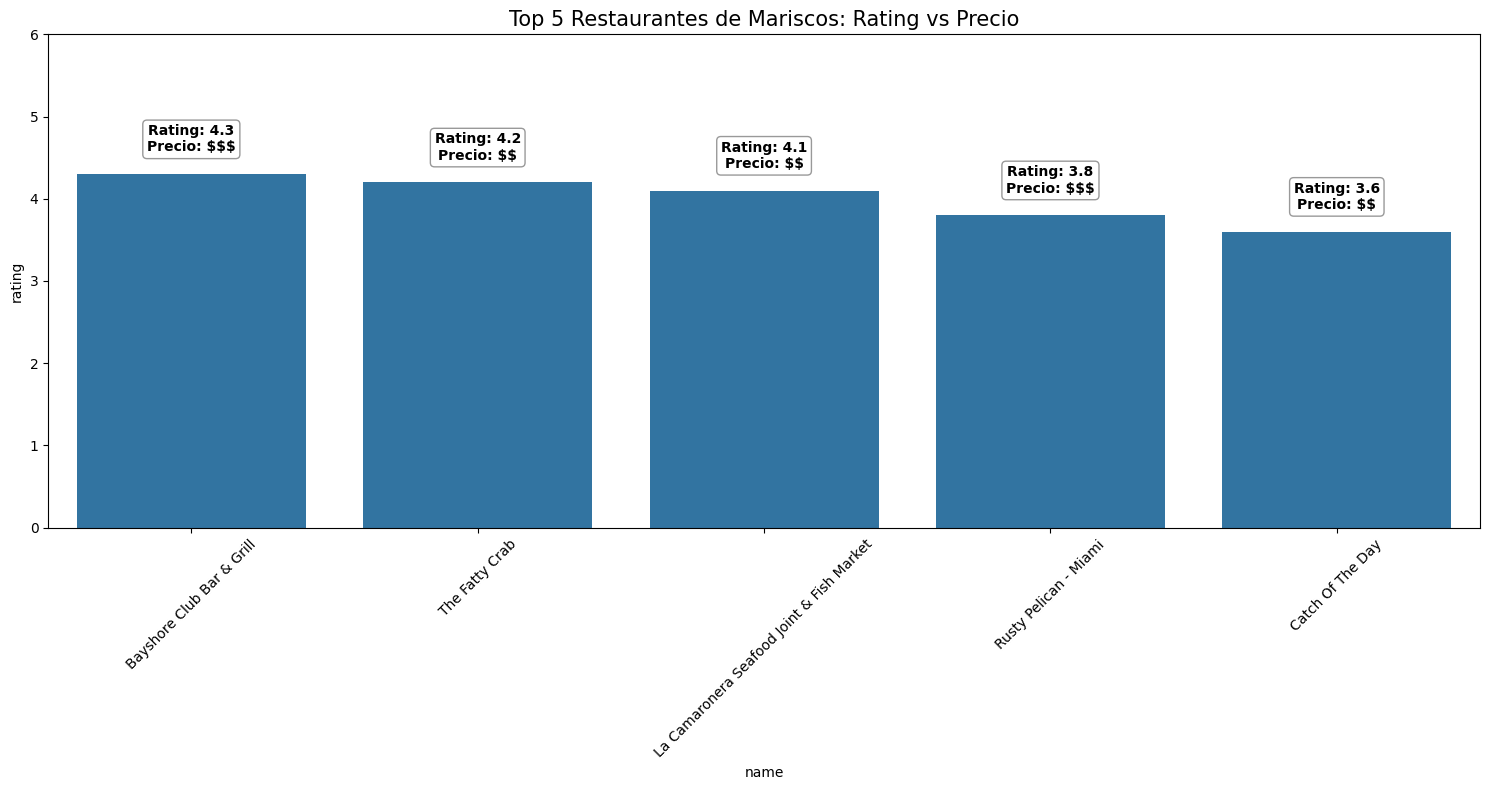

In [40]:

plt.figure(figsize=(15, 8))
ax = sns.barplot(x='name', y='rating', data = top_5_mariscos)

for i, p in enumerate(ax.patches):
    precio_raw = top_5_mariscos.iloc[i]['price']
    # FIX: Reemplazo cada '$' por '\$' para que Matplotlib no lo tome como fórmula matemática
    if pd.notna(precio_raw):
        simbolo_precio = str(precio_raw).replace('$', r'\$')
    else:
        simbolo_precio = "?"
    
    # Dibujar la anotación
    ax.annotate(f"Rating: {p.get_height()}\nPrecio: {simbolo_precio}", #Obtiene el valor exacto del rating para escribirlo.
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 25), # Subo un poco más el texto para q no se superponga con la barra
                textcoords = 'offset points', #indica que la etiqueta debe ir encima de la barra. No le doy un punto fijo
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8)) #crea los cuadros de texto blanco

plt.title('Top 5 Restaurantes de Mariscos: Rating vs Precio', fontsize=15)
plt.ylim(0, 6) # Doy espacio para que las etiquetas no se corten en 5
plt.xticks(rotation=45)
plt.tight_layout() # ajusta atomáticamente los elementos del gráfico

plt.show()